<a href="https://colab.research.google.com/github/yuhui-0611/ESAA/blob/main/ESAA_OB_WEEK05_2_Pytorch2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 파이토치 코드 맛보기

< 데이터 columns >

- price: 자동차 가격
- maint: 자동차 유지 비용
- doors: 자동차 문 개수
- persons: 수용 인원
- lug_capacity: 수하물 용량
- safety: 안전성
- output: 차 상태 (unacc, acc, good, vgood)
> 나머지 칼럼으로 마지막 칼럼을 예측

In [1]:
! pip install matplotlib
! install seaborn
! pip install scikit-learn

install: missing destination file operand after 'seaborn'
Try 'install --help' for more information.


In [2]:
! pip install --upgrade matplotlib --use-feature=2020-resolver
! pip install --upgrade seaborn --use-feature=2020-resolver
! pip install --upgrade scikit-learn --use-feature=2020-resolver


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

option --use-feature: invalid choice: '2020-resolver' (choose from 'fast-deps', 'truststore', 'no-binary-enable-wheel-cache')

Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

option --use-feature: invalid choice: '2020-resolver' (choose from 'fast-deps', 'truststore', 'no-binary-enable-wheel-cache')

Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [opti

In [3]:
# 코드 2-1 필요한 라이브러리 호출
import torch
import torch.nn as nn
import numpy as np # 벡터 및 행렬 연산에서 매우 편리한 기능을 제공하는 파이썬 라이브러리 패키지
import pandas as pd # 데이터 처리를 위해 널리 사용되는 파이썬 라이브러리 패키지
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# 코드 2-2 데이터 호출
dataset = pd.read_csv('/content/drive/MyDrive/ESAA/car_evaluation.csv')
dataset.head()

,price,maint,doors,persons,lug_capacity,safety,output
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


<Axes: ylabel='count'>

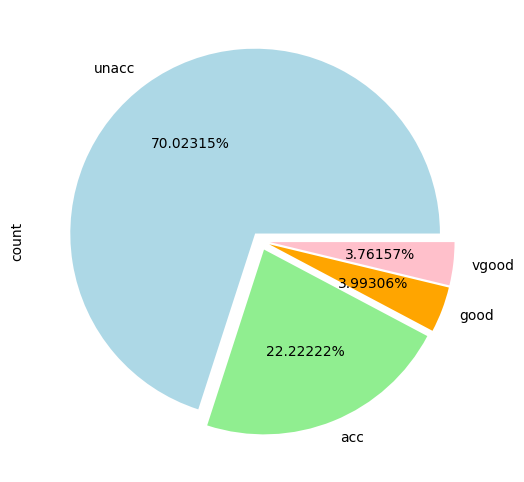

In [7]:
# 코드 2-3 예제 데이터셋 분포
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 8
fig_size[1] = 6
plt.rcParams["figure.figsize"] = fig_size
dataset.output.value_counts().plot(kind='pie',autopct='%0.05f%%',
                                   colors=['lightblue','lightgreen','orange','pink'],
                                   explode=(0.05,0.05,0.05,0.05))

In [10]:
# 코드 2-4 데이터를 범주형 타입으로 변환
categorical_columns = ['price','maint','doors','persons','lug_capacity','safety']

for category in categorical_columns:
  dataset[category] = dataset[category].astype('category')

price = dataset['price'].cat.codes.values
maint = dataset['maint'].cat.codes.values
doors = dataset['doors'].cat.codes.values
persons = dataset['persons'].cat.codes.values
lug_capacity = dataset['lug_capacity'].cat.codes.values
safety = dataset['safety'].cat.codes.values

categorical_data = np.stack([price, maint, doors, persons, lug_capacity, safety],1)
categorical_data[:10]

array([[3, 3, 0, 0, 2, 1],
       [3, 3, 0, 0, 2, 2],
       [3, 3, 0, 0, 2, 0],
       [3, 3, 0, 0, 1, 1],
       [3, 3, 0, 0, 1, 2],
       [3, 3, 0, 0, 1, 0],
       [3, 3, 0, 0, 0, 1],
       [3, 3, 0, 0, 0, 2],
       [3, 3, 0, 0, 0, 0],
       [3, 3, 0, 1, 2, 1]], dtype=int8)

- 범주형 데이터를 텐서로 변환하기 위해
> 범주형 데이터 → dataset['category'] → 넘파이 배열(NumPy array) → 텐서(Tensor)
- 즉, 파이토치로의 모델 학습을 위해서는 텐서 형태로 변환해야 하는데, 이는 넘파이 배열을 통해 생성 가능
- cat.codes = 범주형 데이터(단어)를 숫자(넘파이 배열)로 변환하기 위함
- np.stack = 두 개 이상의 넘파이 객체를 합칠 때 사용

In [11]:
# 2-5 배열을 텐서로 변환
categorical_data = torch.tensor(categorical_data, dtype=torch.int64)
categorical_data[:10]

tensor([[3, 3, 0, 0, 2, 1],
        [3, 3, 0, 0, 2, 2],
        [3, 3, 0, 0, 2, 0],
        [3, 3, 0, 0, 1, 1],
        [3, 3, 0, 0, 1, 2],
        [3, 3, 0, 0, 1, 0],
        [3, 3, 0, 0, 0, 1],
        [3, 3, 0, 0, 0, 2],
        [3, 3, 0, 0, 0, 0],
        [3, 3, 0, 1, 2, 1]])

In [12]:
# 코드 2-6 레이블로 사용할 칼럼을 텐서로 변환
outputs = pd.get_dummies(dataset.output)
outputs = outputs.values
outputs = torch.tensor(outputs).flatten() # 1차원 텐서로 변환

print(categorical_data.shape)
print(outputs.shape)

torch.Size([1728, 6])
torch.Size([6912])


- ravel(), reshape(-1), flatten()은 텐서/배열의 차원을 바꿀 때 사용
- **워드 임베딩**은 **비슷한 단어가 비슷한 벡터로 표현되도록 하는 방법**
- 임베딩 차원이 클수록 단어 사이의 세부 관계를 더 잘 표현할 수 있음
- 단일 숫자로 바꾼 범주형 데이터를 N차원 벡터로 확장해서 사용
- 임베딩 크기는 보통 각 컬럼의 고유값 개수를 기준으로 정함
- 자주 쓰는 방법은 고유값 수 ÷ 2임
  - 예: price의 고유값이 4개이면 임베딩 크기는 2임

In [13]:
# 코드 2-7 범주형 칼럼을 N차원으로 변환
categorical_column_sizes = [len(dataset[column].cat.categories) for column
                            in categorical_columns]
                            # cat.categories: 범주형 데이터의 실제 범주 이름 목록과 그 순서를 확인
categorical_embedding_sizes = [(col_size,min(50,(col_size+1)//2)) for col_size
                               in categorical_column_sizes]
print(categorical_embedding_sizes)

[(4, 2), (4, 2), (4, 2), (3, 2), (3, 2), (3, 2)]


In [14]:
# 코드 2-8 데이터셋 분리
total_records = 1728
test_records = int(total_records*.2)  # 전체 데이터의 20%를 테스트로 사용

categorical_train_data = categorical_data[:total_records - test_records]
categorical_test_data = categorical_data[total_records - test_records:total_records]
train_outputs = outputs[:total_records - test_records]
test_outputs = outputs[total_records - test_records:total_records]

In [15]:
# 코드 2-9 데이터셋 분리 확인
print(len(categorical_train_data))
print(len(train_outputs))
print(len(categorical_test_data))
print(len(test_outputs))

1383
1383
345
345


In [34]:
# 코드 2-10 모델의 네트워크 생성
class Model(nn.Module):
    def __init__(self, embedding_size, output_size, layers, p=0.4):
        super().__init__()

        self.all_embeddings = nn.ModuleList(
            [nn.Embedding(ni, nf) for ni, nf in embedding_size]
        )
        self.embedding_dropout = nn.Dropout(p)

        all_layers = []
        num_categorical_cols = sum(nf for ni, nf in embedding_size)
        input_size = num_categorical_cols
        # 입력층의 크기를 찾기 위해 범주형 칼럼 개수를 input_size 변수에 저장

        for i in layers:
            all_layers.append(nn.Linear(input_size, i))
            all_layers.append(nn.ReLU(inplace=True))
            all_layers.append(nn.BatchNorm1d(i))
            all_layers.append(nn.Dropout(p))
            input_size = i

        all_layers.append(nn.Linear(layers[-1], output_size))
        self.layers = nn.Sequential(*all_layers)

    def forward(self, x_categorical):
        embeddings = []

        for i, e in enumerate(self.all_embeddings):
            embeddings.append(e(x_categorical[:, i]))

        x = torch.cat(embeddings, 1)
        x = self.embedding_dropout(x)
        x = self.layers(x)

        return x

1. 클래스 형태로 구현되는 모델은 nn.Module을 상속받음
2. __ init __()은 모델에 사용할 파라미터와 신경망 구조를 초기화할 때 사용함
    - self는 자기 자신, 즉 현재 생성된 객체를 의미
    - embedding_size는 범주형 칼럼의 임베딩 크기
    - output_size는 출력층의 크기
    - layers는 은닉층 구조를 담은 목록
    - p는 드롭아웃 비율
3. super().__ init __()은 부모 클래스인 nn.Module의 기능을 가져오기 위해 사용
4. for문을 사용해 신경망의 각 계층을 순서대로 추가
    - Linear는 입력값에 선형 변환을 적용하는 계층
      - 선형 계층은 y = Wx + b 형태로 계산됨
    - ReLU는 활성화 함수로 사용
    - BatchNorm1d는 배치 정규화에 사용
    - Dropout은 과적합 방지에 사용
5. forward() 함수는 입력 데이터를 받아 실제 연산을 수행
    - 모델 객체에 데이터를 넣으면 forward()가 자동으로 실행

In [35]:
# 코드 2-11 Model 클래스의 객체 생성
model = Model(categorical_embedding_sizes, 4, [200,100,50], p=0.4)
print(model)

Model(
  (all_embeddings): ModuleList(
    (0-2): 3 x Embedding(4, 2)
    (3-5): 3 x Embedding(3, 2)
  )
  (embedding_dropout): Dropout(p=0.4, inplace=False)
  (layers): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=100, out_features=50, bias=True)
    (9): ReLU(inplace=True)
    (10): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=50, out_features=4, bias=True)
  )
)


In [36]:
# 코드 2-12 모델의 파라미터 정의
loss_function = nn.CrossEntropyLoss()  # 크로스 엔트로피 손실 함수 사용
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [37]:
# 코드 2-13 CPU/GPU 사용 지정
if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')

In [38]:
# 코드 2-14 모델 학습
epochs = 500
aggregated_losses = []
train_outputs = train_outputs.to(device=device, dtype=torch.int64)

for i in range(epochs):  # for 문은 500회 반복되며, 각 반복마다 손실 함수가 오차를 계산
    i += 1
    y_pred = model(categorical_train_data).to(device)
    single_loss = loss_function(y_pred, train_outputs)
    aggregated_losses.append(single_loss)

    if i % 25 == 1:
        print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')

    optimizer.zero_grad()
    single_loss.backward()  # 가중치 업데이트를 위함
    optimizer.step()   # 옵티마이저 함수의 step() 메서드를 이용하여 기울기 업데이트

print(f'epoch: {i:3} loss: {single_loss.item():10.10f}')

epoch:   1 loss: 1.60406852
epoch:  26 loss: 1.41470635
epoch:  51 loss: 1.30417097
epoch:  76 loss: 1.22625232
epoch: 101 loss: 1.07146847
epoch: 126 loss: 0.93816268
epoch: 151 loss: 0.81931704
epoch: 176 loss: 0.74196267
epoch: 201 loss: 0.68167615
epoch: 226 loss: 0.66592509
epoch: 251 loss: 0.62749809
epoch: 276 loss: 0.62675244
epoch: 301 loss: 0.61175120
epoch: 326 loss: 0.59109277
epoch: 351 loss: 0.58916420
epoch: 376 loss: 0.58953798
epoch: 401 loss: 0.57676733
epoch: 426 loss: 0.57482916
epoch: 451 loss: 0.57205170
epoch: 476 loss: 0.56744963
epoch: 500 loss: 0.5730494261


- 에포크마다 출력된 오차 정보를 보여줌

In [39]:
# 코드 2-15 테스트 데이터셋으로 모델 예측
test_outputs = test_outputs.to(device=device, dtype=torch.int64)
with torch.no_grad():
  y_val = model(categorical_test_data)
  loss = loss_function(y_val, test_outputs)
print(f'Loss:{loss:.8f}')

Loss:0.53959924


In [40]:
# 코드 2-16 모델의 예측 확인
print(y_val[:5])

tensor([[ 2.6996,  1.2734, -3.1019, -3.0418],
        [ 2.1503,  1.2094, -3.6237, -3.3460],
        [ 2.3884,  0.9638, -3.3456, -3.1848],
        [ 2.1592,  1.3301, -2.8539, -2.8647],
        [ 2.0677,  1.2024, -2.7260, -2.8608]])


In [41]:
# 코드 2-17 가장 큰 값을 갖는 인덱스 확인
y_val = np.argmax(y_val,axis=1)
print(y_val[:5])

tensor([0, 0, 0, 0, 0])


In [42]:
# 코드 2-18 테스트 데이터셋을 이용한 정확도 확인
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

print(confusion_matrix(test_outputs, y_val))
print(classification_report(test_outputs, y_val)) # Corrected typo: test_outs to test_outputs
print(accuracy_score(test_outputs, y_val))

[[257   2]
 [ 80   6]]
              precision    recall  f1-score   support

           0       0.76      0.99      0.86       259
           1       0.75      0.07      0.13        86

    accuracy                           0.76       345
   macro avg       0.76      0.53      0.50       345
weighted avg       0.76      0.76      0.68       345

0.7623188405797101
